In [ ]:
import marimo as mo

# Ingesta de calles de Hermosillo (INEGI, Marco Geoestadístico 2025)

Los avisos de Agua de Hermosillo nombran **cruces de
calles** ("Palermo y Córcega", "Gerona entre Navas y Gracianas"). Para ubicarlos
necesitamos las calles como geometría. El **Marco Geoestadístico** del INEGI trae
la capa de **ejes de vialidad**: una línea por tramo de calle, con su nombre y tipo.

## Objetivos del experimento
1. Descargar solo la capa de calles del paquete estatal de Sonora (~73 MB con todas
   las capas), con la fuente declarada en `params.yml` y el cliente del INEGI.
2. Leerla y entender su esquema y su sistema de coordenadas.
3. Explorar las calles de la ciudad de Hermosillo: tipos, longitudes y nombres repetidos.
4. Validar que sirven para ubicar los cruces de un aviso real, contra los pines del
   propio volante y contra Google Maps.

In [ ]:
import difflib
import math
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from project_name.clients.http import HttpClient
from project_name.clients.inegi import InegiClient
from project_name.config import load_dataset_config, load_params
from project_name.policies.file import FilePolicy, OnExists

In [ ]:
params = load_params()
dataset = load_dataset_config(params, source="inegi", dataset="mg_2025_sonora")

raw_dir = Path(dataset["raw"]["directory"])
dataset

## Descarga
Un shapefile son varios archivos (`.shp` geometría, `.dbf` atributos, `.shx`
índice, `.prj` proyección, `.CPG` codificación). `download_zip_member` saca cada uno
del ZIP estatal remoto con peticiones HTTP por rango: ~11 MB en vez de ~73 MB.
La política `on_exists: skip` omite los que ya están en `data/raw/`.

In [ ]:
policy = FilePolicy(on_exists=OnExists(dataset["download"]["on_exists"]))
client = InegiClient(http_client=HttpClient(file_policy=policy))

for streets_member in dataset["streets_members"]:
    client.download_zip_member(
        url=dataset["url"],
        member=streets_member,
        destination=raw_dir / Path(streets_member).name,
    )

for downloaded in sorted(raw_dir.iterdir()):
    print(f"{downloaded.name:10} {downloaded.stat().st_size / 1e6:6.1f} MB")

streets_file = raw_dir / "26e.shp"

2026-09-18 15:19:47.378 | INFO     | project_name.clients.http:download_zip_member:56 - Skipping existing file: data/raw/inegi/mg/26e.shp
2026-09-18 15:19:47.378 | INFO     | project_name.clients.http:download_zip_member:56 - Skipping existing file: data/raw/inegi/mg/26e.shx
2026-09-18 15:19:47.378 | INFO     | project_name.clients.http:download_zip_member:56 - Skipping existing file: data/raw/inegi/mg/26e.dbf
2026-09-18 15:19:47.378 | INFO     | project_name.clients.http:download_zip_member:56 - Skipping existing file: data/raw/inegi/mg/26e.prj
2026-09-18 15:19:47.378 | INFO     | project_name.clients.http:download_zip_member:56 - Skipping existing file: data/raw/inegi/mg/26e.CPG


26e.CPG       0.0 MB
26e.dbf      41.7 MB
26e.prj       0.0 MB
26e.shp      22.7 MB
26e.shx       1.8 MB


## Lectura de la capa
La capa `26e` usa la misma proyección del DCAH, **EPSG:6372** (Cónica Conforme de
Lambert sobre ITRF2008, en metros), pero su `.prj` la nombra distinto
(`MEXICO_ITRF_2008_LCC`) y geopandas no la reconoce como EPSG:6372. La convertimos
explícitamente para poder cruzarla con las colonias.

| Campo | Contenido |
|---|---|
| `CVEGEO` | clave geoestadística del tramo |
| `CVE_ENT`, `CVE_MUN`, `CVE_LOC` | entidad, municipio y localidad |
| `CVEVIAL`, `CVESEG` | clave de la vialidad y del segmento |
| `NOMVIAL`, `TIPOVIAL` | nombre y tipo (Calle, Avenida, Retorno…) |
| `SENTIDO`, `TIPOSEN` | sentido de circulación |
| `AMBITO` | urbana o rural |

In [ ]:
streets = gpd.read_file(streets_file).to_crs(epsg=6372)

print(streets.shape)
print(streets.crs.name, "| EPSG:", streets.crs.to_epsg())
streets.head()

(229303, 12)
Mexico ITRF2008 / LCC | EPSG: 6372


,CVEGEO,CVE_ENT,CVE_MUN,CVE_LOC,CVEVIAL,CVESEG,NOMVIAL,TIPOVIAL,SENTIDO,TIPOSEN,AMBITO,geometry
0,2600100030000200013,26,001,0003,00002,00013,Ninguno,Calle,Dos sentidos,2,Rural,"LINESTRING (1706174.388 1991581.813, 1706158.102 1991661.581)"
1,2600100030000300005,26,001,0003,00003,00005,Ninguno,Calle,Un sentido,1,Rural,"LINESTRING (1706154.622 1992037.383, 1706146.791 1992033.048)"
2,2600100010004300002,26,001,0001,00043,00002,Corona,Calle,Dos sentidos,2,Urbana,"LINESTRING (1704715.584 1995482.671, 1704749.499 1995485.606, 1704753.369 1995480.236)"
3,2600100070000800002,26,001,0007,00008,00002,Ninguno,Calle,Dos sentidos,2,Rural,"LINESTRING (1707041.158 1989816.507, 1707029.813 1989828.363)"
4,2600100010002200005,26,001,0001,00022,00005,Reforma,Calle,Dos sentidos,2,Urbana,"LINESTRING (1704677.019 1995738.465, 1704644.733 1995728.841)"


## Calles de la ciudad
Filtramos por municipio (`030`) y localidad (`0001`, la ciudad), renombramos las
columnas a inglés y normalizamos los nombres (sin acentos ni puntuación, en
mayúsculas) para poder compararlos con el texto de los avisos.

In [ ]:
def normalize_name(name: str) -> str:
    # Quita acentos y puntuación, y unifica mayúsculas y espacios para comparar nombres.
    ascii_name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode()
    return " ".join(re.sub(r"[^A-Za-z0-9 ]", " ", ascii_name).upper().split())

In [ ]:
HERMOSILLO_MUNICIPALITY = "030"
CITY_LOCALITY = "0001"

columns = {
    "CVEGEO": "geo_code",
    "CVE_ENT": "state_code",
    "CVE_MUN": "municipality_code",
    "CVE_LOC": "locality_code",
    "CVEVIAL": "street_code",
    "CVESEG": "segment_code",
    "NOMVIAL": "street_name",
    "TIPOVIAL": "street_type",
    "SENTIDO": "direction",
    "TIPOSEN": "direction_code",
    "AMBITO": "scope",
    "geometry": "geometry",
}

city_streets = (
    streets[
        (streets["CVE_MUN"] == HERMOSILLO_MUNICIPALITY) & (streets["CVE_LOC"] == CITY_LOCALITY)
    ]
    .rename(columns=columns)
    .set_geometry("geometry")
)
city_streets["street_key"] = city_streets["street_name"].map(normalize_name)
# Longitud en metros, válida porque EPSG:6372 está en metros.
city_streets["length_m"] = city_streets.length

print(
    f"{len(city_streets)} tramos, {city_streets['street_key'].nunique()} calles distintas, "
    f"{city_streets['length_m'].sum() / 1000:,.0f} km"
)
city_streets.drop(columns="geometry").head()

41538 tramos, 6494 calles distintas, 3,486 km


,geo_code,state_code,municipality_code,locality_code,street_code,segment_code,street_name,street_type,direction,direction_code,scope,street_key,length_m
87287,2603000010909200002,26,030,0001,09092,00002,Quirinales Sur,Retorno,Un sentido,1,Urbana,QUIRINALES SUR,90.505552
87288,2603000010590600001,26,030,0001,05906,00001,Creta,Avenida,Dos sentidos,2,Urbana,CRETA,88.340597
87289,2603000010590500001,26,030,0001,05905,00001,Bangor,Privada,Dos sentidos,2,Urbana,BANGOR,11.226896
87290,2603000010590400001,26,030,0001,05904,00001,Rodas,Avenida,Dos sentidos,2,Urbana,RODAS,119.632747
87291,2603000010543900001,26,030,0001,05439,00001,San Miguel,Avenida,Dos sentidos,2,Urbana,SAN MIGUEL,94.223723


In [ ]:
# Kilómetros por tipo de vialidad.
(city_streets.groupby("street_type")["length_m"].sum() / 1000).sort_values(
    ascending=False
).round(1).head(12)

,length_m
street_type,
Calle,1707.4
Avenida,846.7
Boulevard,435.7
Cerrada,139.1
Privada,136.8
...,...
Circuito,31.7
Carretera,25.8
Calzada,10.3


### Nombres repetidos
Un mismo nombre puede corresponder a calles distintas en distintos fraccionamientos
(cada una con su propia `street_code`). Para ubicar un cruce esto importa: "San
Bruno" existe en dos lugares de la ciudad, así que el nombre solo no basta.

In [ ]:
streets_per_name = city_streets.groupby("street_key")["street_code"].nunique()
repeated = streets_per_name[streets_per_name > 1].sort_values(ascending=False)

print(f"{len(repeated)} de {len(streets_per_name)} nombres se repiten en calles distintas")
repeated.head(15)

1882 de 6494 nombres se repiten en calles distintas


,street_code
street_key,
NINGUNO,2029
B,27
A,25
C,24
D,18
...,...
JESUS SIQUEIROS,12
LAS RIBERAS,12
SAN PEDRO,12


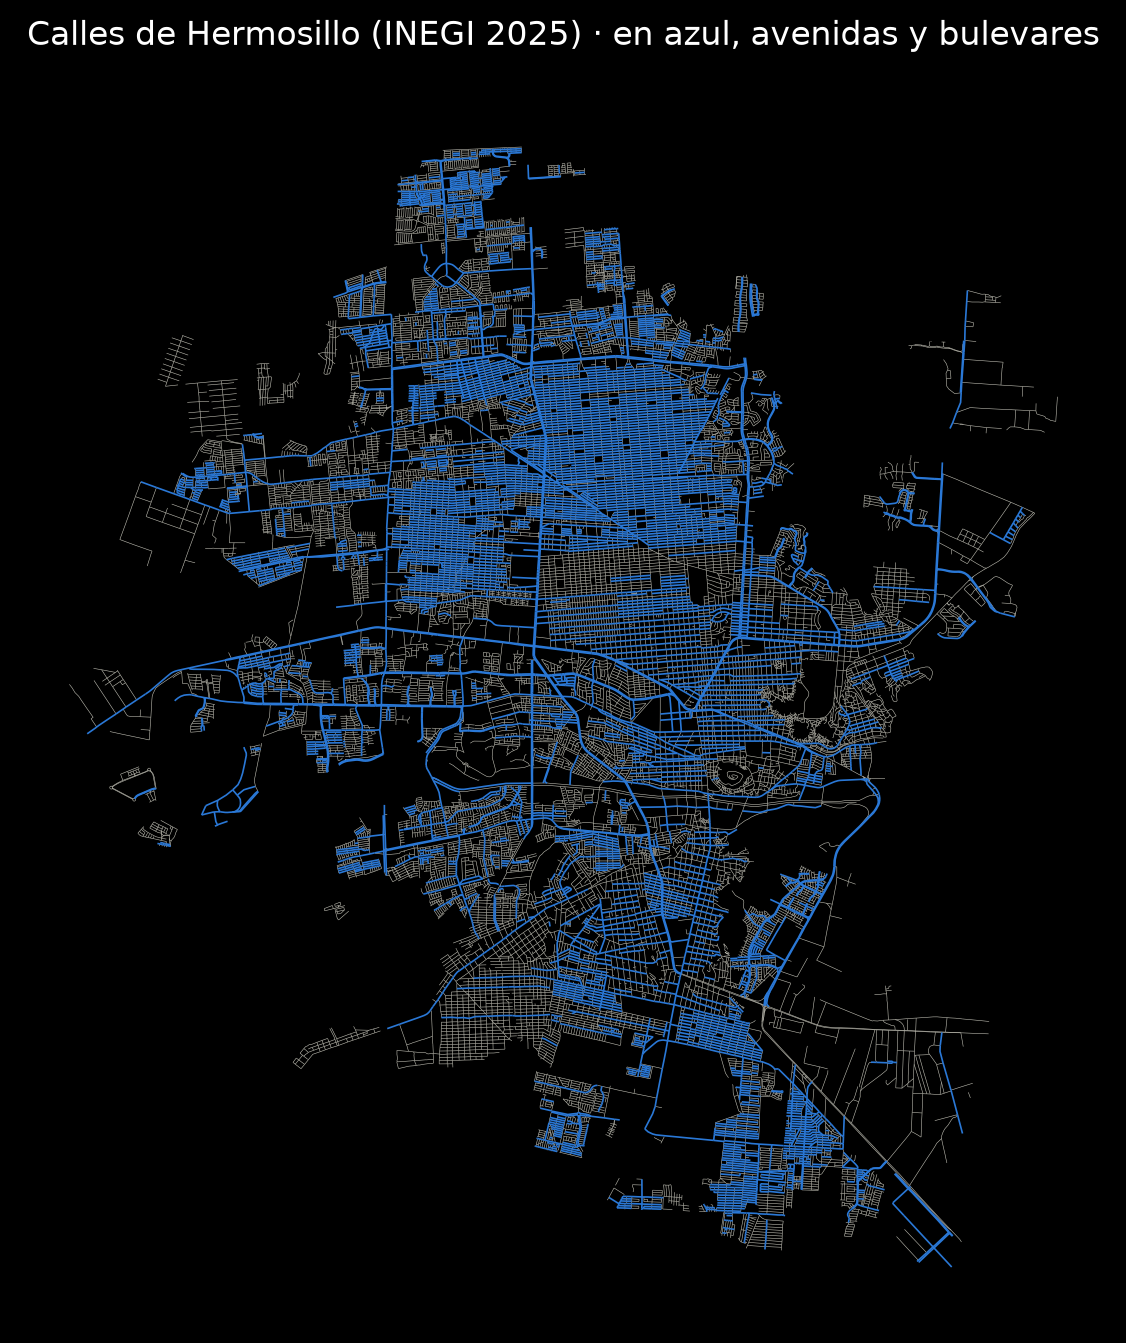

In [ ]:
# Las avenidas y bulevares estructuran la ciudad; el resto de las calles, de fondo.
is_main = city_streets["street_type"].isin(["Avenida", "Boulevard", "Periférico"])

fig_streets, ax_streets = plt.subplots(figsize=(8, 8))
city_streets[~is_main].plot(ax=ax_streets, color="#c3c2b7", linewidth=0.2)
city_streets[is_main].plot(ax=ax_streets, color="#2a78d6", linewidth=0.6)
ax_streets.set_title("Calles de Hermosillo (INEGI 2025) · en azul, avenidas y bulevares")
ax_streets.set_axis_off()
fig_streets

## Validación con un aviso real
El aviso del 28 de octubre de 2025 (publicación `1261580606014208`) trae un mapa
tenue con 17 pines y, abajo, 17 viñetas de reparaciones. Si las calles del INEGI
sirven para ubicar los cruces del texto, los puntos deben reproducir los pines.

Para asignarle una colonia a cada punto usamos las colonias del DCAH que extrae
`01-job-ingestion-colonias-dcah-marimo.py` (hay que correrlo antes).

In [ ]:
colonias_dataset = load_dataset_config(params, source="inegi", dataset="dcah_2025")
colonias_file = (
    Path(colonias_dataset["interim"]["directory"]) / "conjunto_de_datos" / "26as.shp"
)
assert colonias_file.exists(), (
    "Corre primero notebooks/01-job-ingestion-colonias-dcah-marimo.py"
)

colonias = gpd.read_file(colonias_file)
city = colonias[(colonias["cve_mun"] == "030") & (colonias["cve_loc"] == "0001")].rename(
    columns={"nom_asen": "settlement_name"}
)
print(f"{len(city)} colonias en la ciudad")

762 colonias en la ciudad


In [ ]:
POST_ID = "1261580606014208"

ocr_results = pd.concat(
    pd.read_csv(ocr_file, dtype=str)
    for ocr_file in Path(params["ocr"]["output_dir"]).glob("*/ocr_*.csv")
)
ocr_text = ocr_results.loc[ocr_results["id"] == POST_ID, "text"].item()
post_image = next(Path("data/external/facebook/images").glob(f"*/{POST_ID}_*.jpg"))

print(ocr_text)

ALGUNAS DE LAS REPARACIONES QUE TENEMOS PROGRAMADAS PARA ESTE 28 DE OCTUBRE SON:
Gerona entre Navas y Gracianas
• Tejera e Hímanez
Lagasca entre Realeza y Aguiar
• Del Alamo y Venadillo
· Retorno 105 #163
• Mariano Escobedo entre Everardo
Monroy y Coahuila
• Dos y Ángel Carcia Aburto
Casa Blanca entre Del Razo y Argel
Peri y Paseo Montecarlo
• Francisco Javier Mina y Zafiro
Badiraguato e Independencia
Palermo y Córcega
• República de Haiti y Martin de Valencia
• Navojoa y Carlos Balderrama
San Bruno y Antonio Quiroga
Lázaro Mercado y Etchoropo
AquaHermosillo AquaDeHermosillo www.aguahermosillo.gob.mx


In [ ]:
def parse_ocr_lines(text: str) -> list[str]:
    # Cada línea del OCR es una viñeta del volante. "Mariano Escobedo entre
    # Everardo" y "Monroy y Coahuila" parecen una frase cortada, pero en el volante
    # son dos viñetas y el mapa tiene 17 pines (dos juntos cerca de San Benito),
    # así que se quedan como dos ubicaciones.
    lines = [raw_line.strip(" •·▪-\t") for raw_line in text.splitlines()]
    # Fuera el encabezado ("...SON:"), el pie ("www...") y las líneas vacías.
    return [line for line in lines if line and not line.endswith(":") and "www." not in line]

ocr_lines = parse_ocr_lines(ocr_text)
print(f"{len(ocr_lines)} viñetas")
ocr_lines

17 viñetas


In [ ]:
ARTICLES = ("DE LOS ", "DE LAS ", "DE LA ", "DEL ", "LOS ", "LAS ", "LA ", "EL ")
# El volante escribe "Dos" y el INEGI "2". Solo como nombre exacto, para no
# atrapar calles como "2 de Abril".
NUMBER_WORDS = {
    "UNO": "1", "DOS": "2", "TRES": "3", "CUATRO": "4", "CINCO": "5",
    "SEIS": "6", "SIETE": "7", "OCHO": "8", "NUEVE": "9", "DIEZ": "10",
}  # fmt: skip
# Correcciones verificadas a mano (Google Maps y posición de los pines del volante):
# reescriben la viñeta con los nombres que usa el INEGI, porque ninguna regla
# general las resuelve con seguridad.
MANUAL_REWRITES = {
    # El volante y Google dicen "San Bruno"; el INEGI llama "San Francisco" a esa
    # avenida. Cruza Antonio Quiroga entre Sóstenes Rocha y Huatabampo, a 5 m del
    # punto de Google Maps. (Hay otra "San Bruno" a 3.6 km, por eso no hay regla.)
    "San Bruno y Antonio Quiroga": "San Francisco y Antonio Quiroga",
}
# El único "Retorno 105" del INEGI está en Modelo, pero el pin del volante está en
# el sur, junto a las viñetas 11 y 12, donde los retornos no tienen ese nombre. No
# la ubicamos por nombre: la celda siguiente la ubica con el propio volante.
LOCATED_FROM_FLYER = {"Retorno 105 #163"}
street_names = sorted(city_streets["street_key"].unique())

def street_candidates(name: str) -> set[str]:
    # Calles que contienen el nombre buscado como palabra completa: el aviso dice
    # "Mariano Escobedo" y la cartografía "General Mariano Escobedo". También sin
    # artículo ("Del Álamo" -> "Avenida del Álamo"). Si nada coincide, toleramos
    # errores del OCR ("Carcia" -> "García").
    key = normalize_name(name)
    variants = {key} | {key.removeprefix(a) for a in ARTICLES if key.startswith(a)}
    found = {n for n in street_names for v in variants if re.search(rf"\b{re.escape(v)}\b", n)}
    if key in NUMBER_WORDS and NUMBER_WORDS[key] in street_names:
        found.add(NUMBER_WORDS[key])
    return found or set(difflib.get_close_matches(key, street_names, n=1, cutoff=0.8))

def street_segments(keys: set[str]) -> gpd.GeoDataFrame:
    return city_streets.loc[city_streets["street_key"].isin(keys), ["geometry"]]

def similar_touching(known: set[str], name: str, min_ratio=0.6, min_margin=0.1) -> set[str]:
    # Cuando una calle del cruce no existe con ese nombre en el INEGI ("Himanez"
    # aparece como "Hernandez"), la buscamos solo entre las calles que tocan a la
    # otra.
    touching = gpd.sjoin(
        city_streets[["street_key", "geometry"]],
        street_segments(known),
        predicate="dwithin",
        distance=1.0,
    )["street_key"].unique()
    key = normalize_name(name)
    scores = sorted(
        (
            (difflib.SequenceMatcher(None, key, t).ratio(), t)
            for t in touching
            if t not in known
        ),
        reverse=True,
    )
    if not scores or scores[0][0] < min_ratio:
        return set()
    runner_up = scores[1][0] if len(scores) > 1 else 0.0
    return {scores[0][1]} if scores[0][0] - runner_up >= min_margin else set()

def crossing_points(first: set[str], second: set[str], tolerance_m: float = 50.0) -> list:
    # Pares (punto, separación en metros) donde se encuentran las dos calles. A cada
    # tramo de la primera le buscamos el tramo más cercano de la segunda a menos de
    # tolerance_m (0 m si se cruzan). La tolerancia cubre calles que en la
    # cartografía no comparten nodo (Everardo Monroy y Coahuila quedan a 47 m) y es
    # menor a media cuadra, para no confundir calles paralelas.
    if not first or not second:
        return []
    segments_b = street_segments(second)
    pairs = gpd.sjoin_nearest(
        street_segments(first), segments_b, max_distance=tolerance_m, distance_col="gap_m"
    )
    if pairs.empty:
        return []
    # Solo los pares más cercanos: si las calles se cruzan, únicamente los cruces.
    gap = pairs["gap_m"].min()
    closest = pairs[pairs["gap_m"] <= gap + 0.01]
    # El cruce es el punto medio de la línea más corta entre los dos tramos; si se
    # tocan, esa línea mide 0 y su punto medio es el cruce mismo.
    links = closest.geometry.shortest_line(
        segments_b.geometry.loc[closest["index_right"]], align=False
    )
    midpoints = links.interpolate(0.5, normalized=True)
    # Dos tramos que llegan al mismo nodo dan el mismo cruce; lo contamos una vez.
    midpoints = midpoints[~midpoints.set_precision(0.1).duplicated()]
    return [(point, gap) for point in midpoints]

def center(points: list):
    # Centro de uno o varios puntos, p. ej. los dos extremos de "A entre B y C".
    return gpd.GeoSeries(points, crs=city_streets.crs).union_all().centroid

def locate_crossing(main: str, cross: str) -> list:
    main_keys, cross_keys = street_candidates(main), street_candidates(cross)
    if main_keys and not cross_keys:
        cross_keys = similar_touching(main_keys, cross)
    elif cross_keys and not main_keys:
        main_keys = similar_touching(cross_keys, main)
    return crossing_points(main_keys, cross_keys)

def locate_address(street_type: str | None, name: str) -> list:
    # Sin rangos de números de casa, una dirección se ubica en su calle: un punto
    # sobre el tramo. "Retorno 105": el INEGI guarda "105" como nombre y "Retorno"
    # como tipo de vialidad. La búsqueda exacta va primero: la aproximada sobre
    # "Retorno 105" completo atrapaba otra calle a 6.6 km, en El Triunfo.
    segments = city_streets[city_streets["street_key"] == normalize_name(name)]
    if street_type:
        segments = segments[
            segments["street_type"].map(normalize_name) == normalize_name(street_type)
        ]
    if segments.empty:
        # El tipo puede ser parte del nombre ("Paseo Montecarlo #5").
        keys = street_candidates(f"{street_type or ''} {name}")
        segments = city_streets[city_streets["street_key"].isin(keys)]
    if segments.empty:
        return []
    return [(segments.dissolve().representative_point().iloc[0], None)]

def locate(line: str) -> list:
    # "A entre B y C" -> tramo de A entre sus cruces con B y C; "A entre B" y
    # "A y B" -> cruce de A con B; "Tipo Nombre #123" -> dirección.
    address = re.match(r"(?:(\w+) )?(.+?) #\s*\d+$", line)
    if address:
        return locate_address(*address.groups())
    crossing = (
        re.match(r"(.+?) entre (.+?) y (.+)$", line)
        or re.match(r"(.+?) entre (.+)$", line)
        or re.match(r"(.+?) [ye] (.+)$", line)
    )
    if not crossing:
        return []
    main, *crosses = crossing.groups()
    return [found for cross in crosses for found in locate_crossing(main, cross)]

def precision(found: list) -> str | None:
    if not found:
        return None
    gaps = [gap for _, gap in found]
    if None in gaps:
        return "calle (dirección)"
    return "cruce exacto" if max(gaps) == 0 else f"cruce aproximado ({max(gaps):.0f} m)"

located = gpd.GeoDataFrame(
    [
        {
            "number": number,
            "location": line,
            "manual_fix": line in MANUAL_REWRITES or line in LOCATED_FROM_FLYER,
            "precision": precision(found),
            "geometry": center([point for point, _ in found]) if found else None,
        }
        for number, line in enumerate(ocr_lines, start=1)
        for found in [
            [] if line in LOCATED_FROM_FLYER else locate(MANUAL_REWRITES.get(line, line))
        ]
    ],
    geometry="geometry",
    crs=city.crs,
)

# Colonia (DCAH) donde cae cada punto. Uno justo en el límite entre dos colonias
# empata en distancia; nos quedamos con una sola.
with_colonia = (
    gpd.sjoin_nearest(
        located[located.geometry.notna()], city[["settlement_name", "geometry"]], how="left"
    )
    .drop(columns="index_right")
    .drop_duplicates("number")
)
geocoded = pd.concat([with_colonia, located[located.geometry.isna()]]).sort_values("number")

print(f"Ubicados por nombre {with_colonia['number'].nunique()} de {len(located)}")
geocoded.drop(columns="geometry")

Ubicados por nombre 16 de 17


,number,location,manual_fix,precision,settlement_name
0,1,Gerona entre Navas y Gracianas,False,cruce exacto,Puerta del Rey Etapa II
1,2,Tejera e Hímanez,False,cruce exacto,Puerta del Rey Etapa V
2,3,Lagasca entre Realeza y Aguiar,False,cruce exacto,Puerta Real Residencial IX
3,4,Del Alamo y Venadillo,False,cruce exacto,Privadas del Bosque
4,5,Retorno 105 #163,True,NaN,NaN
...,...,...,...,...,...
12,13,Palermo y Córcega,False,cruce exacto,Peñasco
13,14,República de Haiti y Martin de Valencia,False,cruce exacto,Progresista
14,15,Navojoa y Carlos Balderrama,False,cruce exacto,Camino Real
15,16,San Bruno y Antonio Quiroga,True,cruce exacto,San Francisco


### Viñeta 5, ubicada por el volante
El mapa del volante conserva ángulos y proporciones, así que la posición de un pin
se puede medir respecto a otros dos ya ubicados. En los píxeles, el vector 11→5 es
el vector 11→12 girado unos -105° y 1.27 veces más largo; aplicamos esa misma
rotación y escala al vector 11→12 real, con `GeoSeries.rotate` y `GeoSeries.scale`:
giramos el punto 12 alrededor del 11 y escalamos la distancia.

In [ ]:
# Puntas de los pines del volante (píxeles; "y" crece hacia abajo), detectadas por color.
FLYER_PINS = {11: (279, 241), 12: (270, 232), 5: (293, 233)}

def from_flyer(target: int, origin: int = 11, reference: int = 12):
    (ox, oy), (rx, ry), (tx, ty) = (FLYER_PINS[n] for n in (origin, reference, target))
    # Ángulo y escala de origin→target respecto a origin→reference, medidos en el
    # volante. En la imagen "y" crece hacia abajo; en el mapa, hacia el norte.
    angle = math.atan2(oy - ty, tx - ox) - math.atan2(oy - ry, rx - ox)
    factor = math.hypot(tx - ox, ty - oy) / math.hypot(rx - ox, ry - oy)
    points = geocoded.set_index("number").geometry
    moved = (
        points.loc[[reference]]
        .rotate(angle, origin=points[origin], use_radians=True)
        .scale(factor, factor, origin=points[origin])
    )
    return moved.iloc[0]

flyer_point = from_flyer(5)
flyer_settlement = gpd.sjoin_nearest(
    gpd.GeoDataFrame(geometry=[flyer_point], crs=city.crs),
    city[["settlement_name", "geometry"]],
)["settlement_name"].iat[0]

intersections = geocoded.copy()
row = intersections.index[intersections["number"] == 5][0]
intersections.at[row, "geometry"] = flyer_point
intersections.at[row, "precision"] = "estimada del volante"
intersections.at[row, "settlement_name"] = flyer_settlement

print(f"Viñeta 5 -> {flyer_settlement}")
intersections.drop(columns="geometry")

Viñeta 5 -> Pedregal de la Villa


,number,location,manual_fix,precision,settlement_name
0,1,Gerona entre Navas y Gracianas,False,cruce exacto,Puerta del Rey Etapa II
1,2,Tejera e Hímanez,False,cruce exacto,Puerta del Rey Etapa V
2,3,Lagasca entre Realeza y Aguiar,False,cruce exacto,Puerta Real Residencial IX
3,4,Del Alamo y Venadillo,False,cruce exacto,Privadas del Bosque
4,5,Retorno 105 #163,True,estimada del volante,Pedregal de la Villa
...,...,...,...,...,...
12,13,Palermo y Córcega,False,cruce exacto,Peñasco
13,14,República de Haiti y Martin de Valencia,False,cruce exacto,Progresista
14,15,Navojoa y Carlos Balderrama,False,cruce exacto,Camino Real
15,16,San Bruno y Antonio Quiroga,True,cruce exacto,San Francisco


### Contraste con Google Maps
Las cuatro viñetas que no se ubicaban a la primera se verificaron a mano en Google
Maps. Tres resultaron diferencias de nombre entre fuentes: el volante y Google dicen
"Himanez", "Dos" y "San Bruno", y el INEGI registra en ese mismo punto "Hernandez",
"2" y "San Francisco". Las dos primeras se resuelven con reglas generales (calles
vecinas con nombre parecido; números con letra). "San Bruno" no tiene regla segura
(existe otra en la ciudad y, entre las calles vecinas, "San Francisco" y "San Sergio"
empatan), así que va como corrección manual.

"Retorno 105 #163" no tiene referencia confiable: el único "Retorno 105" del INEGI
está en Modelo, y la búsqueda en Google ("Lomas de Hermosillo 105") queda a 1.5 km
del pin del volante. Por eso se ubicó con el volante, en la celda anterior. Las
correcciones manuales quedan marcadas en la columna `manual_fix`.

In [ ]:
# Coordenadas de Google Maps, verificadas a mano, de las viñetas dudosas.
google_maps = pd.DataFrame(
    [
        (2, "Av. Tejera & C. Himanez", 29.1728665, -111.0108353),
        (8, "Av. Ángel García Aburto & Calle Dos", 29.1120942, -110.956049),
        (16, "Av. San Bruno & Blvd. Antonio Quiroga", 29.1207182, -111.0236282),
    ],
    columns=["number", "reference", "latitude", "longitude"],
)
reference_points = gpd.GeoSeries(
    gpd.points_from_xy(google_maps["longitude"], google_maps["latitude"]), crs=4326
).to_crs(intersections.crs)
our_points = intersections.set_index("number").loc[google_maps["number"], "geometry"]

google_maps["distance_m"] = [
    round(ours.distance(reference)) if ours is not None else None
    for ours, reference in zip(our_points, reference_points)
]
google_maps.drop(columns=["latitude", "longitude"])

,number,reference,distance_m
0,2,Av. Tejera & C. Himanez,2
1,8,Av. Ángel García Aburto & Calle Dos,3
2,16,Av. San Bruno & Blvd. Antonio Quiroga,5


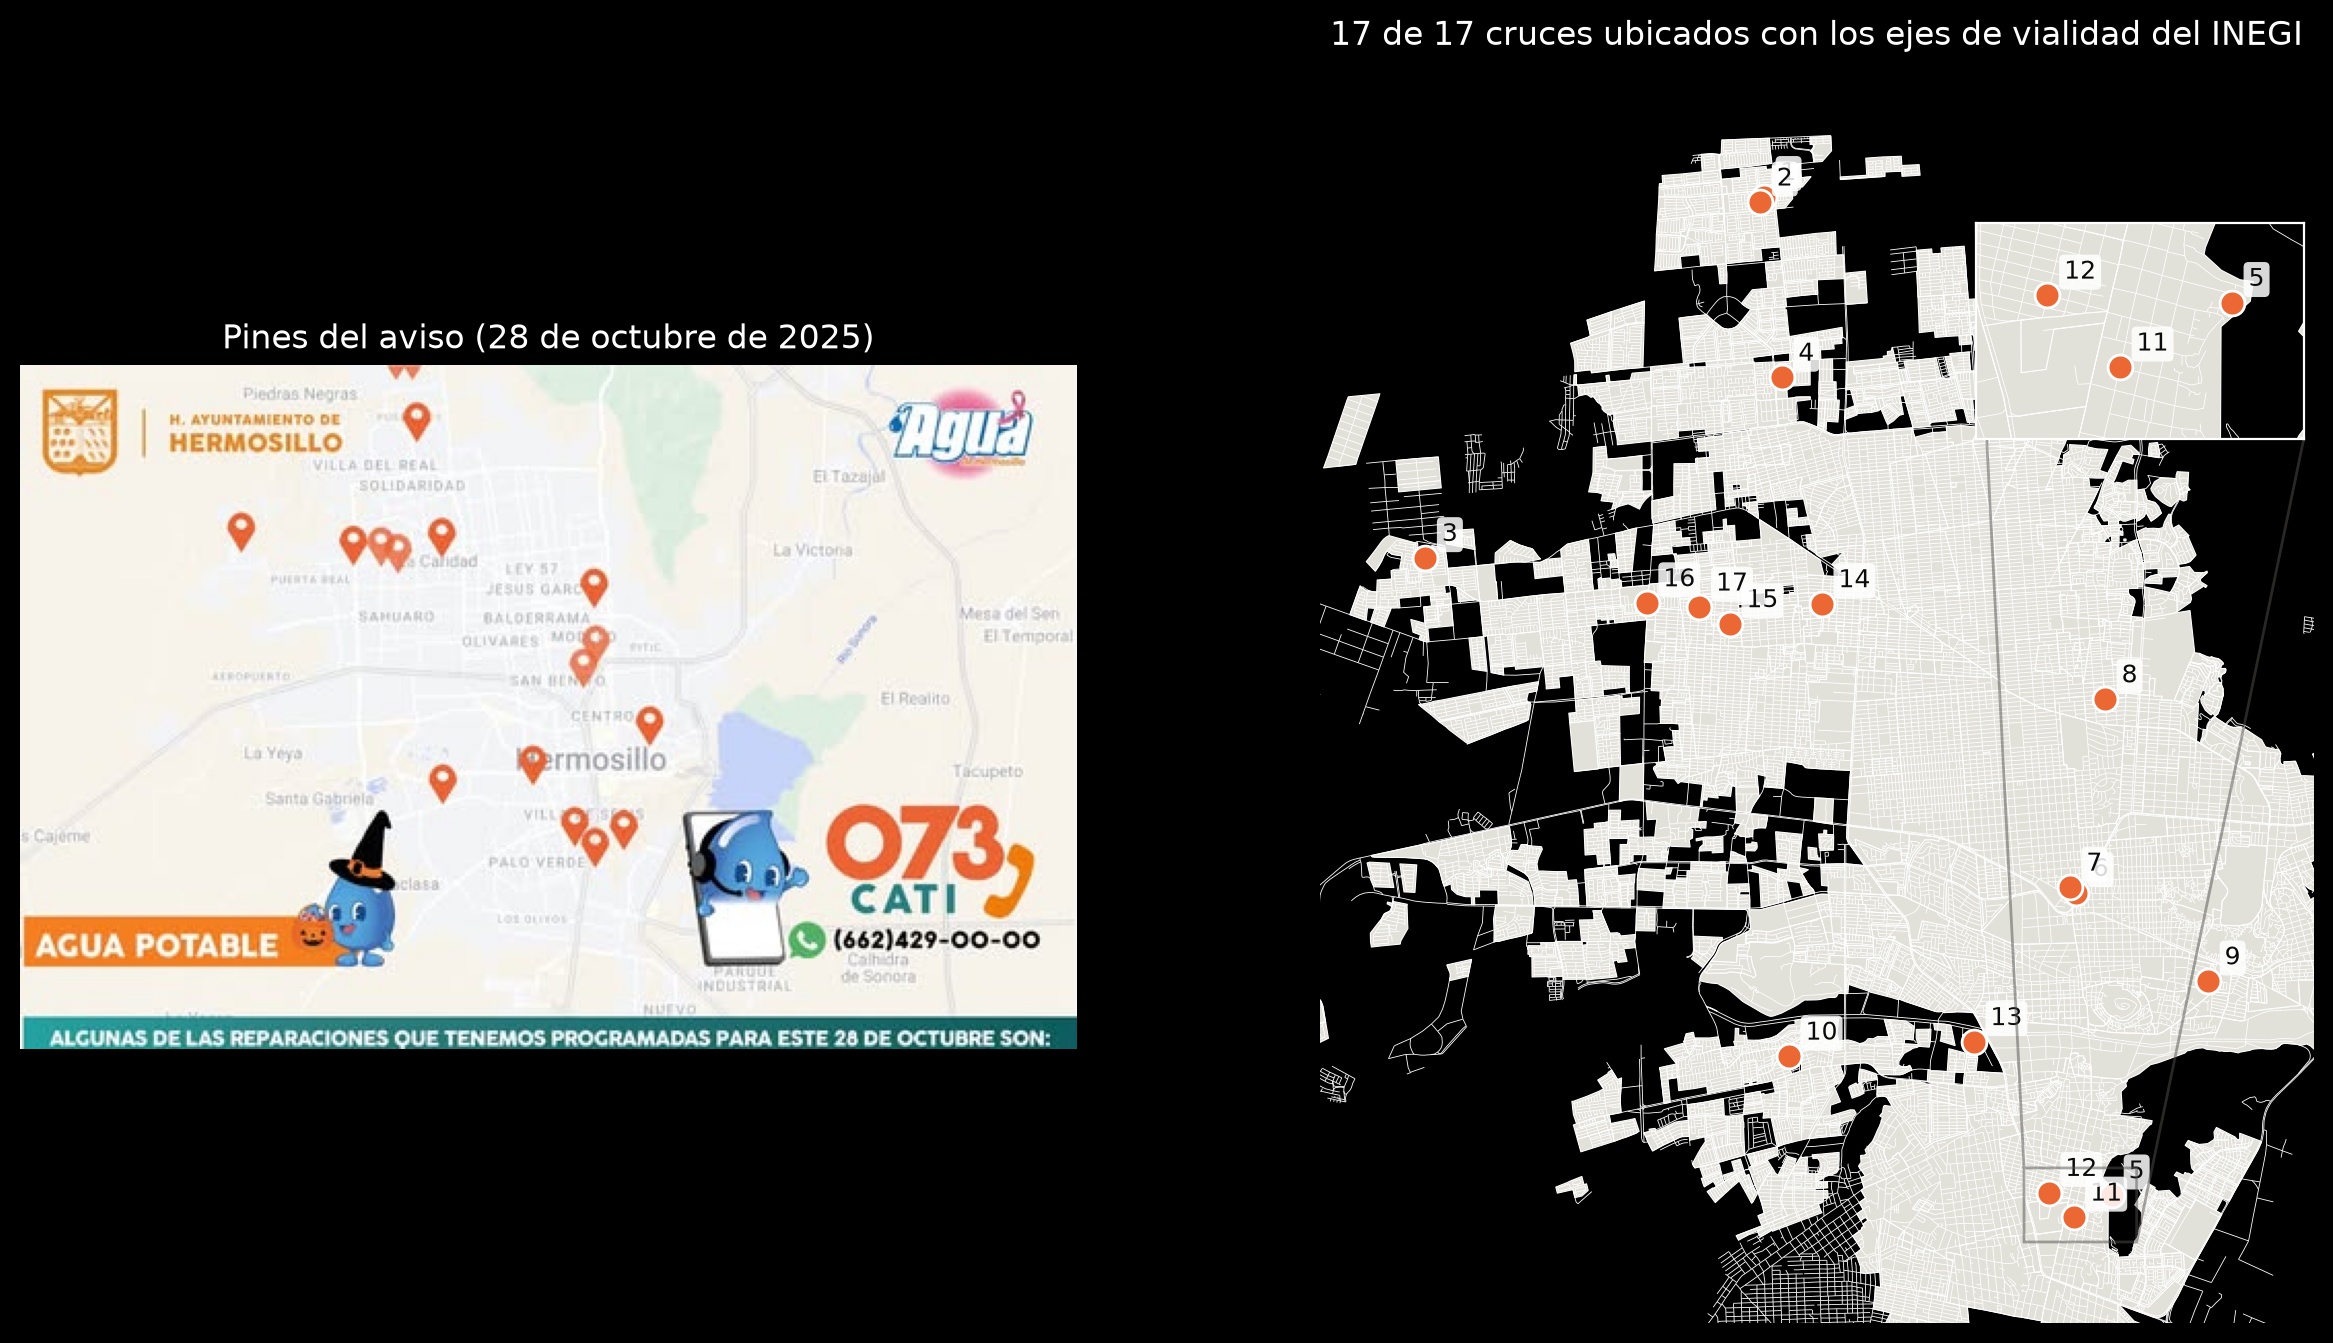

In [ ]:
fig_check, (ax_image, ax_located) = plt.subplots(1, 2, figsize=(15, 8))

# Solo la mitad superior del volante: ahí está el mapa con los pines.
flyer = plt.imread(post_image)
ax_image.imshow(flyer[: int(flyer.shape[0] * 0.52)])
ax_image.set_title("Pines del aviso (28 de octubre de 2025)")
ax_image.set_axis_off()

located_points = intersections[intersections.geometry.notna()]

def draw_map(ax, points, margin_m):
    city.plot(ax=ax, color="#e1e0d9", edgecolor="#ffffff", linewidth=0.4)
    city_streets.plot(ax=ax, color="#ffffff", linewidth=0.3)
    points.plot(
        ax=ax, color="#eb6834", markersize=80, edgecolor="#ffffff", linewidth=1, zorder=3
    )
    for point in points.itertuples():
        # Caja clara bajo cada número para que se lea con tema claro u oscuro.
        ax.annotate(
            str(point.number),
            xy=(point.geometry.x, point.geometry.y),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            color="#0b0b0b",
            bbox={
                "boxstyle": "round,pad=0.2",
                "facecolor": "#ffffff",
                "edgecolor": "none",
                "alpha": 0.85,
            },
            zorder=4,
        )
    x_min, y_min, x_max, y_max = points.total_bounds
    ax.set_xlim(x_min - margin_m, x_max + margin_m)
    ax.set_ylim(y_min - margin_m, y_max + margin_m)

# Encuadre parecido al del volante: los cruces ubicados más 1.5 km de margen.
draw_map(ax_located, located_points, margin_m=1500)
ax_located.set_title(
    f"{located_points['number'].nunique()} de {intersections['number'].nunique()} "
    "cruces ubicados con los ejes de vialidad del INEGI"
)
ax_located.set_axis_off()

# Acercamiento al triángulo 11-12-5, que a escala de ciudad se encima.
ax_zoom = ax_located.inset_axes([0.66, 0.64, 0.33, 0.33])
draw_map(ax_zoom, located_points[located_points["number"].isin([5, 11, 12])], margin_m=350)
ax_zoom.set_xticks([])
ax_zoom.set_yticks([])
ax_located.indicate_inset_zoom(ax_zoom, edgecolor="#52514e")
fig_check

## Hallazgos y siguientes pasos
- La capa de ejes de vialidad ubica 16 de las 17 viñetas del aviso solo con reglas
  generales, y la ubicación reproduce los pines del volante.
- Los errores no vienen del OCR sino de **nombres distintos entre fuentes**: el
  volante y Google dicen "Himanez", "Dos" y "San Bruno"; el INEGI, "Hernandez",
  "2" y "San Francisco". Conviene mantener una tabla de correcciones verificadas.
- Siguiente: pasar la geocodificación de avisos a `project_name/` con sus pruebas
  (las referencias de Google Maps sirven como casos), y convertir la descarga en
  un job (`ingest_mg_streets_job`).